In [2]:
import mne
import numpy as np
from numpy import matlib as mb
import matplotlib.pyplot as plt
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
import warnings
from collections import defaultdict
import matplotlib.pyplot as plt
from mne.preprocessing import ICA
from mne.preprocessing import Xdawn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LinearRegression
from scipy.stats import t
from sklearn import metrics
from sklearn.metrics import roc_auc_score as get_auc
from models.LDA import LDAClassifier
from src.Speller import Speller
from src.Dataset import Dataset
warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("WARNING")

/home/users/ag796/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/users/ag796/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/users/ag796/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


Error Analysis with Visualization

Let's take Patients 7, 10, and 2 into account because none of the models performed well their metrics

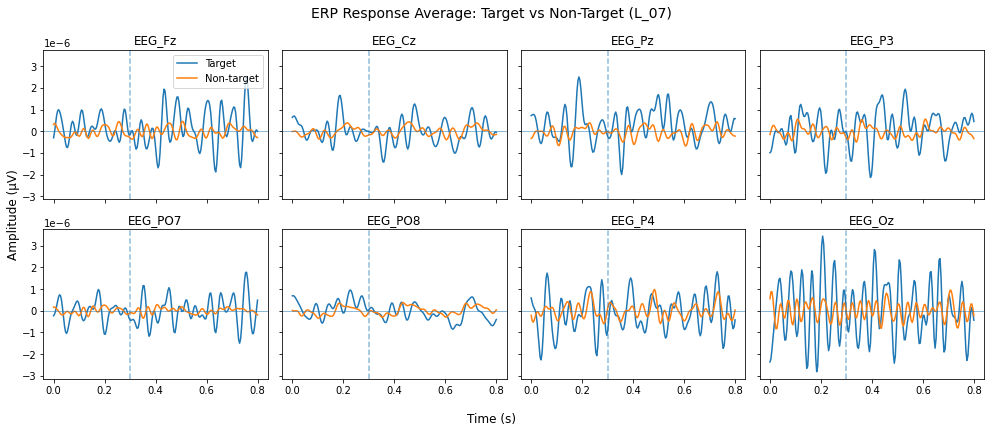

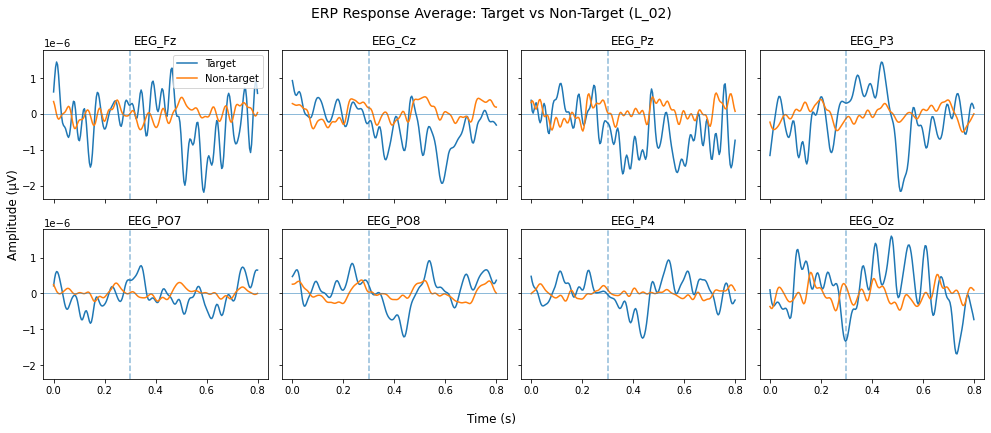

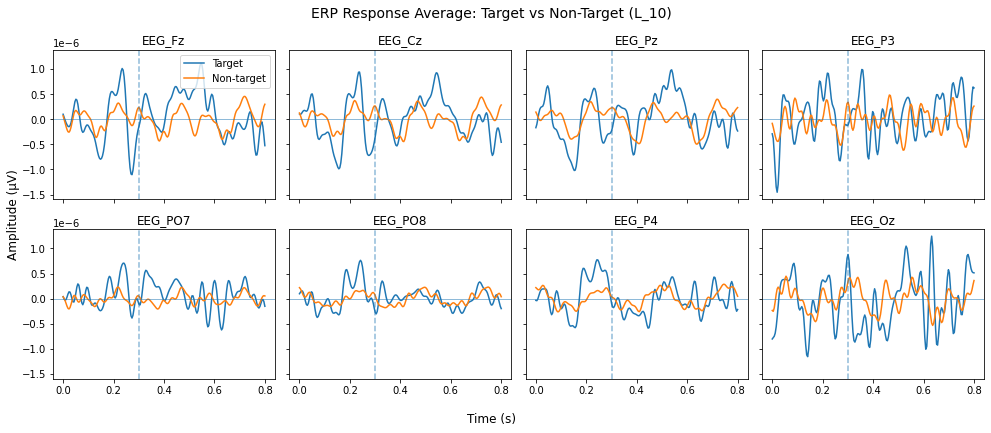

In [6]:
important_channels = ['EEG_Fz', 'EEG_Cz', 'EEG_Pz', 'EEG_P3','EEG_PO7', 'EEG_PO8', 'EEG_P4', 'EEG_Oz']

def plot_erp(patient_id):

    ds = Dataset(
        glob_path=os.path.join(project_root, "data", patient_id, "*", "*", "CB", "*"),
        tmin=0,
        tmax=0.8,
        use_car=True,
        notch_filter=True
    )

    X, y = ds[0]
    times = np.linspace(ds.tmin, ds.tmax, X.shape[2])

    X_target = X[y == 1]
    X_nontarget = X[y == 0]

    target = X_target.mean(axis=0)
    nontarget = X_nontarget.mean(axis=0)

    fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True)
    axes = axes.flatten()

    for ch_idx, ax in enumerate(axes):
        ax.plot(times, target[ch_idx], label="Target")
        ax.plot(times, nontarget[ch_idx], label="Non-target")
        ax.set_title(important_channels[ch_idx])
        ax.axvline(0.3, linestyle="--", alpha=0.5)
        ax.axhline(0, linewidth=0.5)

    axes[0].legend(loc="upper right")

    fig.suptitle(f"ERP Response Average: Target vs Non-Target ({patient_id})", fontsize=14)
    fig.supxlabel("Time (s)")
    fig.supylabel("Amplitude (µV)")

    plt.tight_layout()
    plt.show()


# model fails in these cases
for pid in ["L_07", "L_02", "L_10"]:
    plot_erp(pid)

Now lets look at a High performing Model (Patient 5)

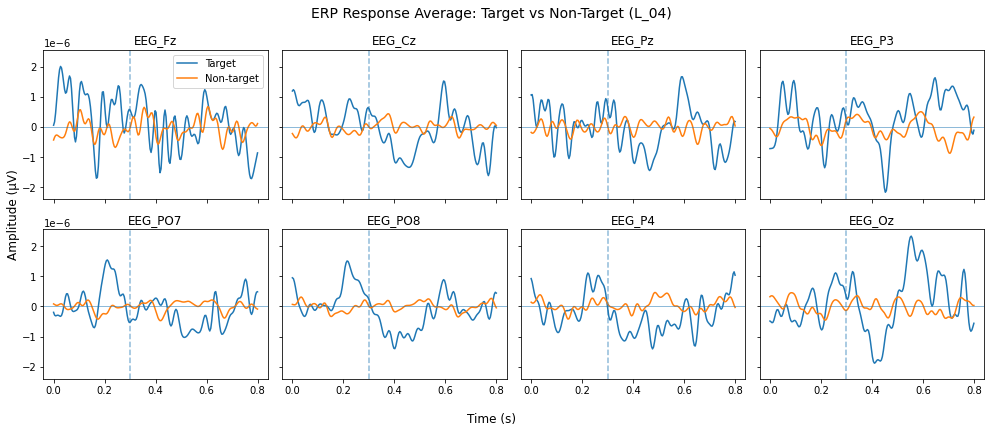

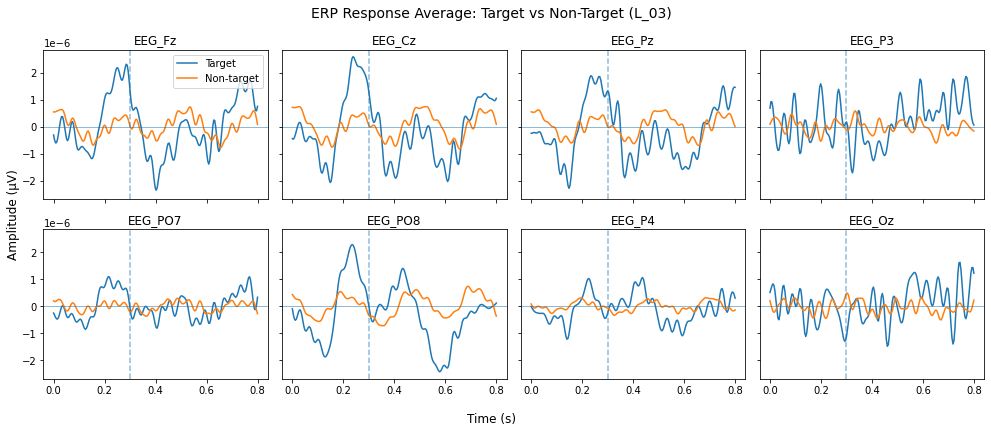

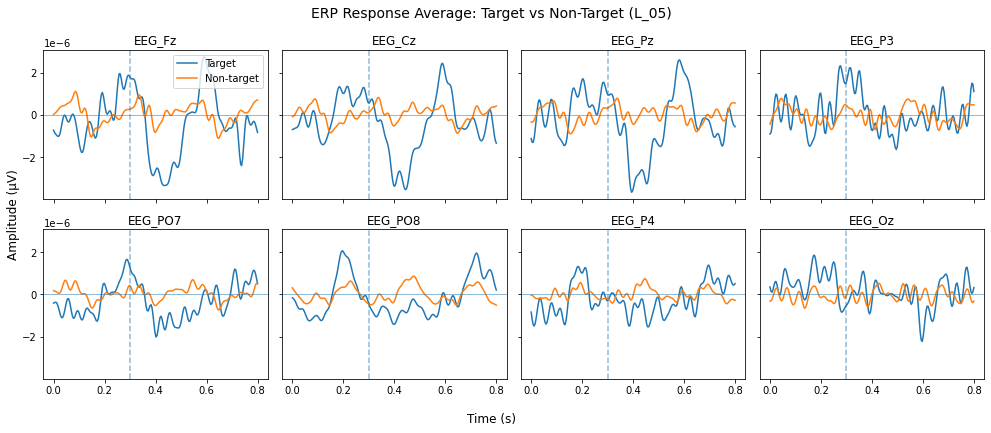

In [9]:
for pid in ["L_04", "L_03", "L_05"]:
    plot_erp(pid)

Averaging all the Failures and Successes together respectively to see common patterns

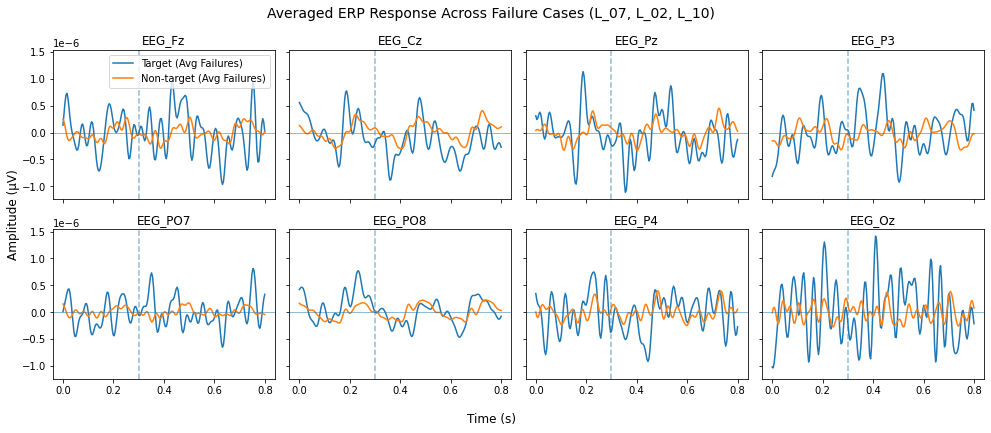

In [16]:
def get_erp(patient_id):

    ds = Dataset(
        glob_path=os.path.join(project_root, "data", patient_id, "*", "*", "CB", "*"),
        tmin=0,
        tmax=0.8,
        use_car=True,
        notch_filter=True
    )

    X, y = ds[0]

    X_target = X[y == 1]
    X_nontarget = X[y == 0]

    target = X_target.mean(axis=0)
    nontarget = X_nontarget.mean(axis=0)

    return target, nontarget

failed_subjects = ["L_07", "L_02", "L_10"]

all_targets = []
all_nontargets = []

for pid in failed_subjects:
    t, n = get_erp(pid)
    all_targets.append(t)
    all_nontargets.append(n)

avg_target = np.mean(all_targets, axis=0)
avg_nontarget = np.mean(all_nontargets, axis=0)

ds_ref = Dataset(
    glob_path=os.path.join(project_root, "data", failed_subjects[0], "*", "*", "CB", "*"),
    tmin=0,
    tmax=0.8,
    use_car=True,
    notch_filter=True
)
_, _ = ds_ref[0]
times = np.linspace(ds_ref.tmin, ds_ref.tmax, avg_target.shape[1])

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ch_idx, ax in enumerate(axes):
    ax.plot(times, avg_target[ch_idx], label="Target (Avg Failures)")
    ax.plot(times, avg_nontarget[ch_idx], label="Non-target (Avg Failures)")
    ax.set_title(important_channels[ch_idx])
    ax.axvline(0.3, linestyle="--", alpha=0.5)
    ax.axhline(0, linewidth=0.5)

axes[0].legend(loc="upper right")

fig.suptitle(
    "Averaged ERP Response Across Failure Cases (L_07, L_02, L_10)",
    fontsize=14
)

fig.supxlabel("Time (s)")
fig.supylabel("Amplitude (µV)")

plt.tight_layout()
plt.show()

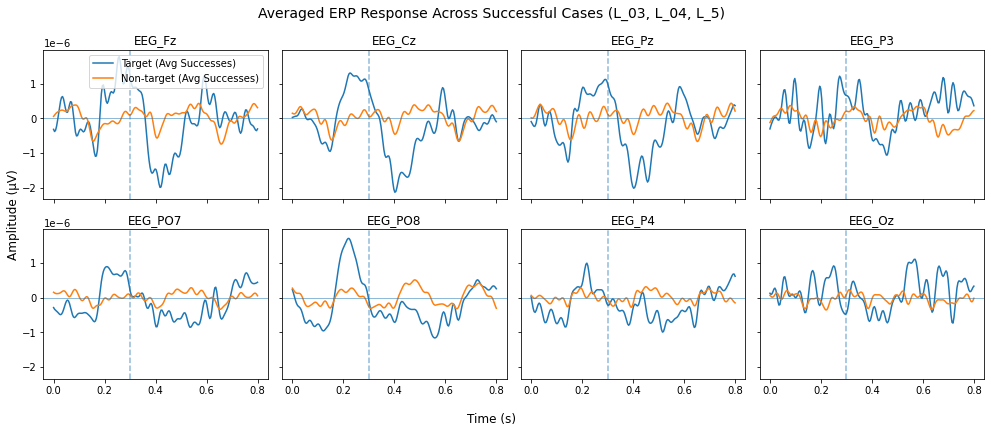

In [17]:
success_subjects = ["L_03", "L_04", "L_05"]

all_targets = []
all_nontargets = []

for pid in success_subjects:
    t, n = get_erp(pid)
    all_targets.append(t)
    all_nontargets.append(n)

avg_target = np.mean(all_targets, axis=0)
avg_nontarget = np.mean(all_nontargets, axis=0)

ds_ref = Dataset(
    glob_path=os.path.join(project_root, "data", success_subjects[0], "*", "*", "CB", "*"),
    tmin=0,
    tmax=0.8,
    use_car=True,
    notch_filter=True
)
_, _ = ds_ref[0]
times = np.linspace(ds_ref.tmin, ds_ref.tmax, avg_target.shape[1])

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ch_idx, ax in enumerate(axes):
    ax.plot(times, avg_target[ch_idx], label="Target (Avg Successes)")
    ax.plot(times, avg_nontarget[ch_idx], label="Non-target (Avg Successes)")
    ax.set_title(important_channels[ch_idx])
    ax.axvline(0.3, linestyle="--", alpha=0.5)
    ax.axhline(0, linewidth=0.5)

axes[0].legend(loc="upper right")

fig.suptitle(
    "Averaged ERP Response Across Successful Cases (L_03, L_04, L_5)",
    fontsize=14
)

fig.supxlabel("Time (s)")
fig.supylabel("Amplitude (µV)")

plt.tight_layout()
plt.show()

From these Visualizations (Independent and Aggregated), it is clear that in the participants that did not perform very well like Participants 2, 7, and 10, that there EEG signals are very noisy and have no clear peak at the 300 ms mark. Therefore it is hard for the model to identify the P300 signal and classify that signal as a target signal for the spelling. However, in the Successful Participants like Participants 3, 4, and 5, there often is a clear peak across the EEG channels at the 300 ms mark which allows models to better predict where a trial target occurs. Clearly, inputs full of noise and randomness in signals prove to be the most challenging. 

This distinction highlights that classification performance is heavily dependent on the quality and consistency of the underlying EEG signal rather than the model itself. When the P300 component is well-defined and temporally stable across trials, even a simple classifier can achieve strong results. When it is absent or buried in noise, no amount of model complexity can reliably gather the signal.

These differences in signal quality across participants are likely driven by a combination of individual variability, differences in attention and engagement during the task, and session-level factors such as electrode impedance and movement artifacts. Taken together, the error analysis suggests that future improvements should focus not only on model architecture but also on signal quality — particularly filtering to get rid of external artifacts, increased data collection lower-performing participants, and potentially adaptive preprocessing pipelines tailored to each individual.